#### Fixed Points + Hamming Analysis

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [18]:
data = pd.read_csv("Data.csv")
data["cycle_fraction"] = data["cycles_runs"] / 100
print(data)

         N    W    k  ETA_w  ETA_s  fp_runs  cycles_runs  max_steps_runs  \
0     1000  0.0  100    0.0   0.00        0            0             100   
1     1000  0.0  100    0.0   0.05        0            0             100   
2     1000  0.0  100    0.0   0.10        0            0             100   
3     1000  0.0  100    0.0   0.15        0            0             100   
4     1000  0.0  100    0.0   0.20        0            0             100   
...    ...  ...  ...    ...    ...      ...          ...             ...   
4846  1000  0.5  100    1.0   0.80        0          100               0   
4847  1000  0.5  100    1.0   0.85        0          100               0   
4848  1000  0.5  100    1.0   0.90        0          100               0   
4849  1000  0.5  100    1.0   0.95        0          100               0   
4850  1000  0.5  100    1.0   1.00        0          100               0   

      fixed_points  updates  hamming  cycle_fraction  
0                0        0     

In [19]:
data.iloc[:, 5].sum()

np.int64(0)

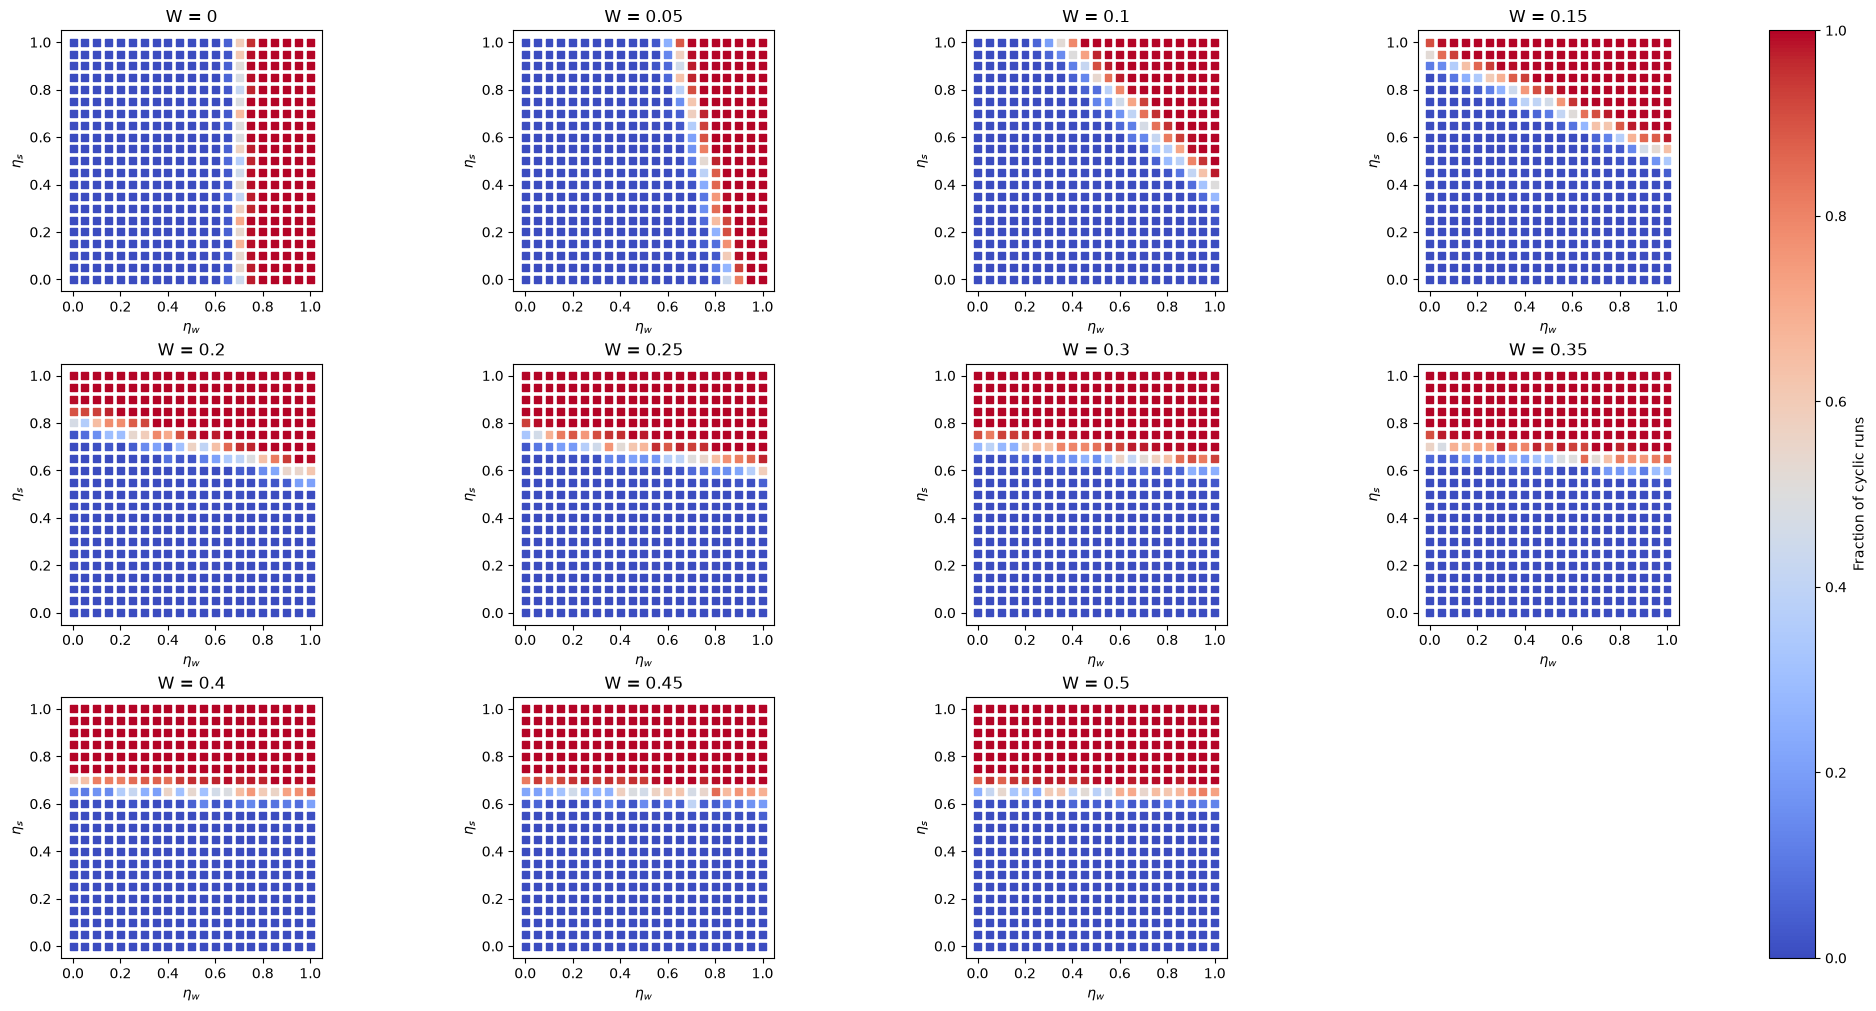

In [27]:
w_values = np.sort(data["W"].unique())

counter = 0

fig, ax = plt.subplots(3, 4, figsize=(20, 10), layout = "constrained")
axes = ax.ravel()

for W in w_values:
    d = data[data["W"] == W]
    sc = axes[counter].scatter(
        d["ETA_w"],
        d["ETA_s"],
        c=d["cycle_fraction"],
        marker="s",
        s=25,
        cmap="coolwarm"
    )

    axes[counter].set_title(f"W = {W:g}")
    axes[counter].set_xlabel(r"$\eta_w$")
    axes[counter].set_ylabel(r"$\eta_s$")
    axes[counter].set_xticks(np.arange(0, 1.2, 0.2))
    axes[counter].set_yticks(np.arange(0, 1.2, 0.2))
    axes[counter].set_aspect("equal")
    counter = counter + 1

axes[-1].axis("off")

fig.colorbar(
    sc,
    ax=ax,
    label="Fraction of cyclic runs"
)
plt.show()